In [1]:
##importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from math import ceil
from sklearn.cluster import KMeans #Kmeans cluster package 

In [2]:
#importing data
data = pd.read_csv("cleaned_dataset.csv")
# check data
print(data.head()) # Prints the first 5 rows of the DataFrame
data.info() #summarize dataframe

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350120      4.0         4     116             26             34    24.8   
2  10350125      4.0         1      35             15              4     4.8   
3  10350125     11.0         0      11             10              0     2.2   
4  10350197      1.0         5     124             36             24    11.0   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     4.87       33          2.0  ...             3.0       1         45.0   
2     0.69        9          1.0  ...             3.0       1          7.0   
3     0.13        1          1.0  ...             3.0       1          1.0   
4     2.44       22          2.0  ...             3.0       1         26.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [3]:
target = ['Choice']

# Socio-demographic variables (Sub-question 1)
socio_demo = ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild']

# Vehicle Ownership & Availability (Sub-question 4)
vehicle = ['NbCar', 'NbMoto', 'CarAvail']

# Spatial context (Sub-question 3)
spatial_context = ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency']

# Trip utility (standard predictors for mode choice)
trip_utility = ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar']

# Historical & Childhood Background
history = ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
                      'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar']

# Attitudinal Statements (Sub-question 2: Environmental and Lifestyle)
attitudes = ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']

critical_cols = target + socio_demo + vehicle + spatial_context + trip_utility + history
critical_data = data[critical_cols]
critical_data.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,MarginalCostPT,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar
0,1.0,27.0,1.0,7.0,1983.0,1,2.0,2.0,0.0,1.0,...,0.0,3.17,1.0,2.0,2,4.0,3.0,5.0,1.0,1.0
1,1.0,64.0,2.0,4.0,1946.0,1,2.0,2.0,0.0,1.0,...,12.4,4.87,3.0,4.0,2,3.0,5.0,5.0,2.0,2.0
2,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,4.8,0.69,3.0,4.0,1,3.0,4.0,3.0,2.0,2.0
3,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,2.2,0.13,3.0,11.0,1,3.0,4.0,3.0,2.0,2.0
4,1.0,30.0,1.0,8.0,1980.0,1,2.0,2.0,0.0,2.0,...,0.0,2.44,1.0,1.0,2,3.0,1.0,5.0,3.0,1.0


In [4]:
#DATA PROCESSING
X = critical_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 
X.columns =  [critical_cols] #attitudes to predict clusters
org_X = X # to keep the version before feature scaling 

# Feature scaling 
X = (X - X.mean()) / X.std()
print(X.head()) # Prints the first 5 rows of the DataFrame

     Choice       age    Gender Education BirthYear  LangCode FamilSitu  \
0  0.409219 -1.450593 -0.958586  1.658364  1.450593 -1.791504 -0.630845   
1  0.409219  1.124165  1.042313 -0.120516 -1.124165 -1.791504 -0.630845   
2  0.409219  1.402517  1.042313 -0.713476 -1.402517 -1.791504 -1.325131   
3  0.409219  1.402517  1.042313 -0.713476 -1.402517 -1.791504 -1.325131   
4  0.409219 -1.241828 -0.958586  2.251325  1.241828 -1.791504 -0.630845   

  NbHousehold   NbChild     NbCar  ... MarginalCostPT   CostCar TripPurpose  \
0   -0.680298 -0.675557 -0.708087  ...      -0.652450 -0.159157   -1.205789   
1   -0.680298 -0.675557 -0.708087  ...       0.114817  0.130976    0.959823   
2   -1.476131 -0.675557 -0.708087  ...      -0.355443 -0.582409    0.959823   
3   -1.476131 -0.675557 -0.708087  ...      -0.516322 -0.677982    0.959823   
4   -0.680298 -0.675557  0.676170  ...      -0.652450 -0.283743   -1.205789   

    DestAct NbTrajects FreqTripHouseh ModeToSchool ResidChild FreqTrainPar

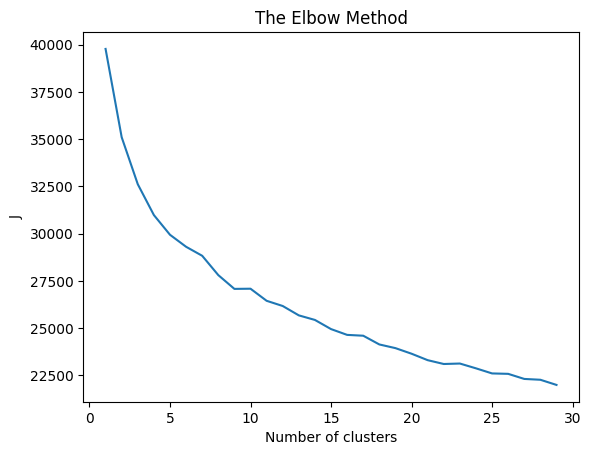

In [6]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [5]:
#implement kmeans algorithm with 6 clusters based on the outcome of the elbow method
kmeans = KMeans(n_clusters=6, random_state=1, n_init="auto").fit(X)

#add column for clusters
data_cluster = X
data_cluster['Cluster']= kmeans.labels_
data_cluster.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar,Cluster
0,0.409219,-1.450593,-0.958586,1.658364,1.450593,-1.791504,-0.630845,-0.680298,-0.675557,-0.708087,...,-0.159157,-1.205789,-0.626836,0.008635,1.128702,-0.985578,0.618219,-1.445620,-1.476360,2
1,0.409219,1.124165,1.042313,-0.120516,-1.124165,-1.791504,-0.630845,-0.680298,-0.675557,-0.708087,...,0.130976,0.959823,-0.060240,0.008635,0.092067,0.773738,0.618219,0.003713,-0.151596,4
2,0.409219,1.402517,1.042313,-0.713476,-1.402517,-1.791504,-1.325131,-1.476131,-0.675557,-0.708087,...,-0.582409,0.959823,-0.060240,-1.114855,0.092067,-0.105920,-0.941985,0.003713,-0.151596,4
3,0.409219,1.402517,1.042313,-0.713476,-1.402517,-1.791504,-1.325131,-1.476131,-0.675557,-0.708087,...,-0.677982,0.959823,1.922844,-1.114855,0.092067,-0.105920,-0.941985,0.003713,-0.151596,4
4,0.409219,-1.241828,-0.958586,2.251325,1.241828,-1.791504,-0.630845,-0.680298,-0.675557,0.676170,...,-0.283743,-1.205789,-0.910133,0.008635,0.092067,-2.744893,0.618219,1.453047,-1.476360,2


In [6]:
data_cluster.columns = [col[0] for col in data_cluster.columns]

In [7]:
#create new datasets per cluster
# Cluster 0
cluster_0 = data_cluster[data_cluster["Cluster"] == 0]
# Cluster 1
cluster_1 = data_cluster[data_cluster["Cluster"] == 1]
# Cluster 2
cluster_2 = data_cluster[data_cluster["Cluster"] == 2]
# Cluster 3
cluster_3 = data_cluster[data_cluster["Cluster"] == 3]
# Cluster 4
cluster_4 = data_cluster[data_cluster["Cluster"] == 4]
# Cluster 5
cluster_5 = data_cluster[data_cluster["Cluster"] == 5]



Centroids are: [[ 0.14480507  0.65637844 -0.1735111  -0.16787072 -0.65637844  0.43535841
  -0.52959528 -0.75767036 -0.65418135 -0.29953885 -0.20496853 -0.14607036
   0.02691232 -0.21122543 -0.07706617  0.41711907  0.33873065 -0.68506011
  -0.49990347 -0.58139966 -0.53768693 -0.48605624 -0.46073986 -0.66555663
  -0.39078579 -0.46342855  0.03116638 -0.00810543 -0.37756489 -0.08430534
   0.1384299   0.05752087  0.2150742   0.11519727]
 [-0.13863147 -0.73668942  0.30816999 -0.13118101  0.73668942  0.5239118
   0.66282344  0.68807666  0.41322713  0.06371088  0.33161782  0.44757155
  -0.0871477   0.09440129  0.07254726  0.45096248  0.15027993 -0.47822002
  -0.37195965 -0.42012675 -0.34847803 -0.33379769 -0.37159442 -0.46470318
  -0.31685947 -0.37209664 -0.09961319 -0.09081179 -0.22172104 -0.04590279
  -0.09642682  0.14398451  0.01413993  0.1200288 ]
 [ 0.29085869 -0.39483294  0.12032998  0.1992172   0.39483294 -1.60725177
   0.00558314  0.56026517  0.68746763  0.33689112  0.08894869 -0.12162

NameError: name 'labels' is not defined

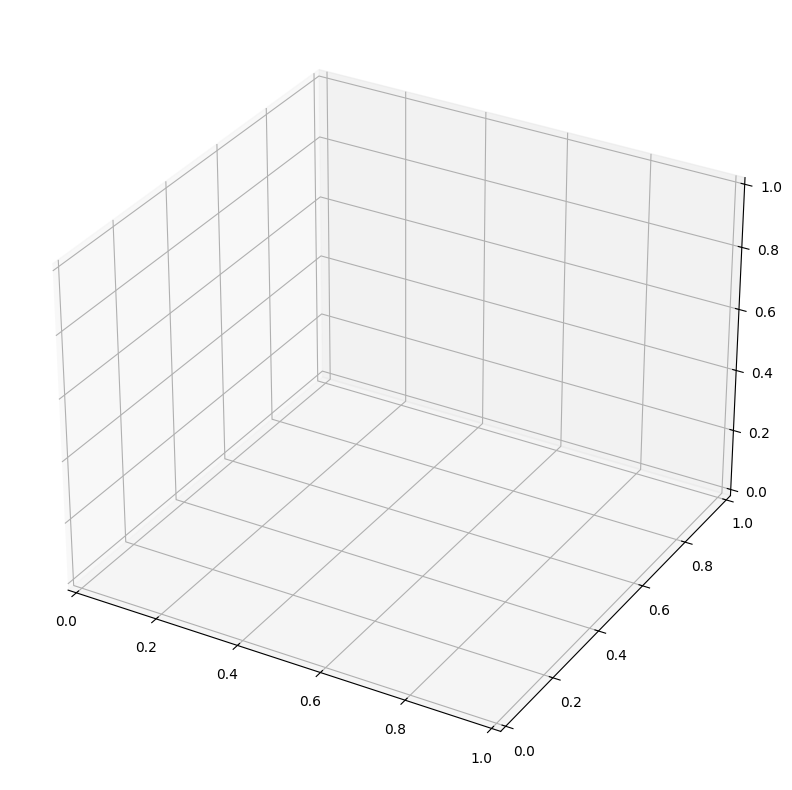

In [8]:
##still to be updated

# plot clusters in 3d 
#labels = kmeans.predict(X)                      # Getting the cluster labels
centroids = kmeans.cluster_centers_             # Centroid values
print("Centroids are:", centroids)              # From sci-kit learn

#plot
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

x = np.array(labels==0)
y = np.array(labels==1)
z = np.array(labels==2)


ax.scatter(X[x][:, 0], X[x][:, 1], X[x][:, 2], color='red')
ax.scatter(X[y][:, 0], X[y][:, 1], X[y][:, 2], color='blue')
ax.scatter(X[z][:, 0], X[z][:, 1], X[z][:, 2], color='yellow')
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            marker='x', s=169, linewidths=10,
            color='black', zorder=50)

## SOURCE: https://stackoverflow.com/questions/64987810/3d-plotting-of-a-dataset-that-uses-k-means

